# Demo of spectroscopy mode with slit and prism features: HR 8799 system

In [25]:
from corgisim import scene
from corgisim import instrument
import matplotlib.pyplot as plt
import numpy as np
import proper
import roman_preflight_proper

In [26]:
### Copy the default prescription file 
roman_preflight_proper.copy_here()

## 1. Configure scene

### We configure a scene with the star HR 8799 (Vmag=6.0, spectral type A5V) and its directly-imaged companion HR 8799 e, using a model planet emission spectrum from a radiative transfer retrieval.

In [27]:
import astropy.units as u
from synphot import SpectralElement
from synphot.models import Empirical1D

# --- Host Star Properties (HR 8799) ---
Vmag = 6.0                          # V-band magnitude of HR 8799
sptype = 'A5V'                      # Spectral type of HR 8799
host_star_properties = {'Vmag': Vmag,
                        'spectral_type': sptype,
                        'magtype': 'vegamag',
                        'ref_flag': False}

# --- Build stellar spectrum via a star-only scene ---
_star_scene = scene.Scene(host_star_properties, [])
sp_star = _star_scene.stellar_spectrum

# --- Load HR 8799 e planet emission model ---
# File columns: wavenumber (cm^-1), thermal flux (erg/s/cm^3), Fp/Fs (dimensionless)
planet_data = np.loadtxt('hr_8799_e_emission_model.txt', comments='#')
wno   = planet_data[:, 0]   # wavenumber in cm^-1
fp_fs = planet_data[:, 2]   # planet-to-star flux ratio

# Convert wavenumber to wavelength in Angstroms, sort ascending
wave_aa = 1e8 / wno
idx = np.argsort(wave_aa)
wave_aa, fp_fs = wave_aa[idx], fp_fs[idx]

# Build planet SourceSpectrum: treat Fp/Fs as a SpectralElement multiplied by the stellar spectrum
fp_fs_ratio = SpectralElement(Empirical1D, points=wave_aa * u.AA, lookup_table=fp_fs)
sp_planet = fp_fs_ratio * sp_star

# Define companion positions in milliarcseconds
mas_per_lamD = 63.72   # Band 3
dra = [2 * mas_per_lamD]        # X position in mas
ddec = [6 * mas_per_lamD]       # Y position in mas

# Companion point source with model planet spectrum
point_source_info = [
    {
        'Vmag': [0],          # Ignored when Custom_Spectrum is defined
        'magtype': 'vegamag', # Ignored when Custom_Spectrum is defined
        'position_x': dra[0],
        'position_y': ddec[0],
        'Custom_Spectrum': sp_planet   # HR 8799 e model
    }
]

# --- Create the Astrophysical Scene ---
base_scene = scene.Scene(host_star_properties, point_source_info)

Adding 0 off-axis sources
Adding 1 off-axis sources


### Stellar spectrum and planet-to-star flux ratio

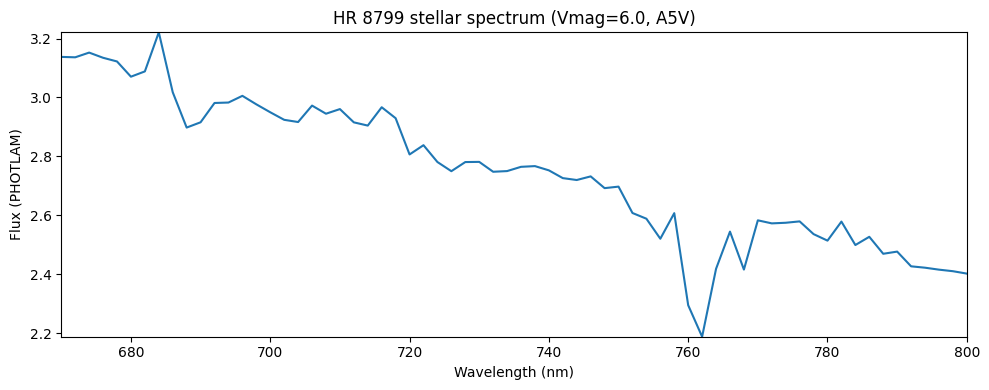

In [28]:
# --- Plot the HR 8799 host star spectrum ---
wave_star_nm = sp_star.waveset.to(u.nm)
flux_star = sp_star(sp_star.waveset)

# Mask to the plot wavelength range for y-axis scaling
mask_star = (wave_star_nm.value >= 670) & (wave_star_nm.value <= 800)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wave_star_nm, flux_star)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Flux (PHOTLAM)')
ax.set_title(f'HR 8799 stellar spectrum (Vmag={Vmag}, {sptype})')
ax.set_xlim(670, 800)
ax.set_ylim(flux_star[mask_star].value.min(), flux_star[mask_star].value.max())
plt.tight_layout()
plt.show()

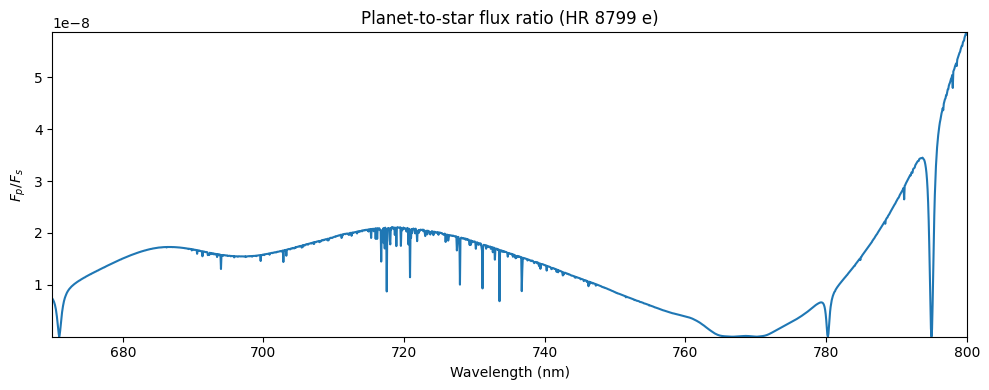

In [29]:
# --- Plot planet-to-star flux ratio for HR 8799 e ---
wave_nm = wave_aa / 10   # Å → nm

# Mask to the plot wavelength range for y-axis scaling
mask_fpfs = (wave_nm >= 670) & (wave_nm <= 800)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wave_nm, fp_fs)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$F_p / F_s$')
ax.set_title('Planet-to-star flux ratio (HR 8799 e)')
ax.set_xlim(670, 800)
ax.set_ylim(fp_fs[mask_fpfs].min(), fp_fs[mask_fpfs].max())
plt.tight_layout()
plt.show()

### Set the coronagraph mode to SPC and use the speckle models with 2E-8 raw contrast.

In [30]:
cgi_mode = 'spec'
cor_type = 'spc-spec_band3'
bandpass = '3F'
# cases = ['2e-8']      
cases = ['1e-9']      
rootname = 'spc-spec_ni_' + cases[0]
dm1 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm1_v.fits' )
dm2 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm2_v.fits' )

### Broadband and narrowband prism images with slit 

#### Set the optics configuration with the FSAM slit mask. Here we specify the R1C2 slit offset by 6.0 lambda/D.

In [31]:
##  Define the polaxis parameter. Use 10 for non-polaxis cases only, as other options are not yet implemented.
polaxis = 10
# output_dim define the size of the output image
output_dim = 121
overfac = 5

## slit location offset in lam/D and mas, relative to host star in sky coordinates, dDEC
source_y_offset = 6.0 #lam/D
source_y_offset_mas = source_y_offset * mas_per_lamD

#set slit keyword to R1C2
#supported slits in band 2 are R6C5 and R3C1
#supported slits in band 3 are R1C2 and R3C1
offset_star_optics_keywords ={'cor_type':cor_type, 'use_errors':0, 'polaxis':polaxis, 'output_dim':output_dim, 
        'use_dm1':1, 'dm1_v':dm1, 'use_dm2':1, 'dm2_v':dm2, 'use_fpm':0, 'use_lyot_stop':1, 'fsm_y_offset':source_y_offset,
        'prism':'PRISM3', 'wav_step_um':2E-3, 'slit':'R1C2', 'slit_dec_offset_mas':source_y_offset_mas} 

optics_slit_prism_cfam3F = instrument.CorgiOptics(cgi_mode, bandpass='3F', optics_keywords=offset_star_optics_keywords, if_quiet=True,
                                oversampling_factor = overfac, return_oversample = False)
optics_slit_prism_cfam3D = instrument.CorgiOptics(cgi_mode, bandpass='3D', optics_keywords=offset_star_optics_keywords, if_quiet=True,
                                oversampling_factor = overfac, return_oversample = False)

CorgiOptics initialized with proper keywords.
CorgiOptics initialized with proper keywords.


### Get the occulted star PSF with the slit in place for each filter case 3F and 3D

In [32]:
sim_unocc_slit_prism_cfam3F = optics_slit_prism_cfam3F.get_host_star_psf(base_scene)
sim_unocc_slit_prism_cfam3D = optics_slit_prism_cfam3D.get_host_star_psf(base_scene)

source location (x, y) without prism = 60.000, 60.000
source location (x, y) with prism = 60.000, 60.001
full frame source location (x, y) with prism = 1600.000, 525.001
source location (x, y) without prism = 60.000, 60.000
source location (x, y) with prism = 60.044, 51.460
full frame source location (x, y) with prism = 1600.044, 516.460


In [33]:
image_unocc_slit_prism_cfam3F = sim_unocc_slit_prism_cfam3F.host_star_image.data
image_unocc_slit_prism_cfam3D = sim_unocc_slit_prism_cfam3D.host_star_image.data

### Set the optics configuration for the target scene, repeated with and without the slit in place.

In [34]:
##  Define the polaxis parameter. Use 10 for non-polaxis cases only, as other options are not yet implemented.
polaxis = 10
# output_dim define the size of the output image
output_dim = 121
overfac = 5

#set slit and prism keywords to none
optics_keywords_noslit_noprism ={'cor_type':cor_type, 'use_errors':1, 'polaxis':polaxis, 'output_dim':output_dim, 
                  'use_dm1':1, 'dm1_v':dm1, 'use_dm2':1, 'dm2_v':dm2,'use_fpm':1, 'use_lyot_stop':1,
                  'slit':'None', 'prism':'None'}

optics_keywords_slit_noprism ={'cor_type':cor_type, 'use_errors':1, 'polaxis':polaxis, 'output_dim':output_dim, 
                  'use_dm1':1, 'dm1_v':dm1, 'use_dm2':1, 'dm2_v':dm2,'use_fpm':1, 'use_lyot_stop':1,
                  'slit':'R1C2', 'slit_dec_offset_mas':base_scene.point_source_ddec[0], 'prism':'None'}

optics_keywords_slit_prism ={'cor_type':cor_type, 'use_errors':1, 'polaxis':polaxis, 'output_dim':output_dim, 
                  'use_dm1':1, 'dm1_v':dm1, 'use_dm2':1, 'dm2_v':dm2,'use_fpm':1, 'use_lyot_stop':1,
                  'slit':'R1C2', 'slit_dec_offset_mas':base_scene.point_source_ddec[0], 'prism':'PRISM3', 'wav_step_um':2E-3}

optics_noslit_noprism = instrument.CorgiOptics(cgi_mode, bandpass, optics_keywords=optics_keywords_noslit_noprism, if_quiet=True,
                                small_spc_grid = 0, oversampling_factor = overfac, return_oversample = False)

optics_slit_noprism = instrument.CorgiOptics(cgi_mode, bandpass, optics_keywords=optics_keywords_slit_noprism, if_quiet=True,
                                small_spc_grid = 1, oversampling_factor = overfac, return_oversample = False)

optics_slit_prism = instrument.CorgiOptics(cgi_mode, bandpass, optics_keywords=optics_keywords_slit_prism, if_quiet=True,
                                small_spc_grid = 1, oversampling_factor = overfac, return_oversample = False)

CorgiOptics initialized with proper keywords.
CorgiOptics initialized with proper keywords.
CorgiOptics initialized with proper keywords.


/Users/nzimmerm/Roman_sims_and_analysis/corgisim/corgisim/instrument.py:199: UserWarning: No prism selected in spec mode, the dispersion model will not be applied to the image cube.
  warnings.warn("No prism selected in spec mode, the dispersion model will not be applied to the image cube.")
/Users/nzimmerm/Roman_sims_and_analysis/corgisim/corgisim/instrument.py:214: UserWarning: No slit selected in spec mode, the slit mask will not be applied to the image cube.
  warnings.warn("No slit selected in spec mode, the slit mask will not be applied to the image cube.")


## 3. On-axis star with companion source



### Images without companion

In [35]:
sim_scene_noslit_noprism = optics_noslit_noprism.get_host_star_psf(base_scene)

In [36]:
sim_scene_slit_noprism = optics_slit_noprism.get_host_star_psf(base_scene)

In [37]:
sim_scene_slit_prism = optics_slit_prism.get_host_star_psf(base_scene)

source location (x, y) without prism = 60.000, 60.000
source location (x, y) with prism = 60.000, 60.001
full frame source location (x, y) with prism = 1600.000, 525.001


In [38]:
image_star_noslit_noprism = sim_scene_noslit_noprism.host_star_image.data
image_star_slit_noprism = sim_scene_slit_noprism.host_star_image.data
image_star_slit_prism = sim_scene_slit_prism.host_star_image.data

### Images with companion

In [39]:
optics_slit_prism.inject_point_sources(base_scene, sim_scene_slit_prism)

In [40]:
optics_noslit_noprism.inject_point_sources(base_scene, sim_scene_noslit_noprism)

In [41]:
image_comp_noslit_noprism = sim_scene_noslit_noprism.point_source_image.data
combined_image_noslit_noprism = image_star_noslit_noprism + image_comp_noslit_noprism

image_comp_slit_prism = sim_scene_slit_prism.point_source_image.data
combined_image_slit_prism = image_star_slit_prism + image_comp_slit_prism

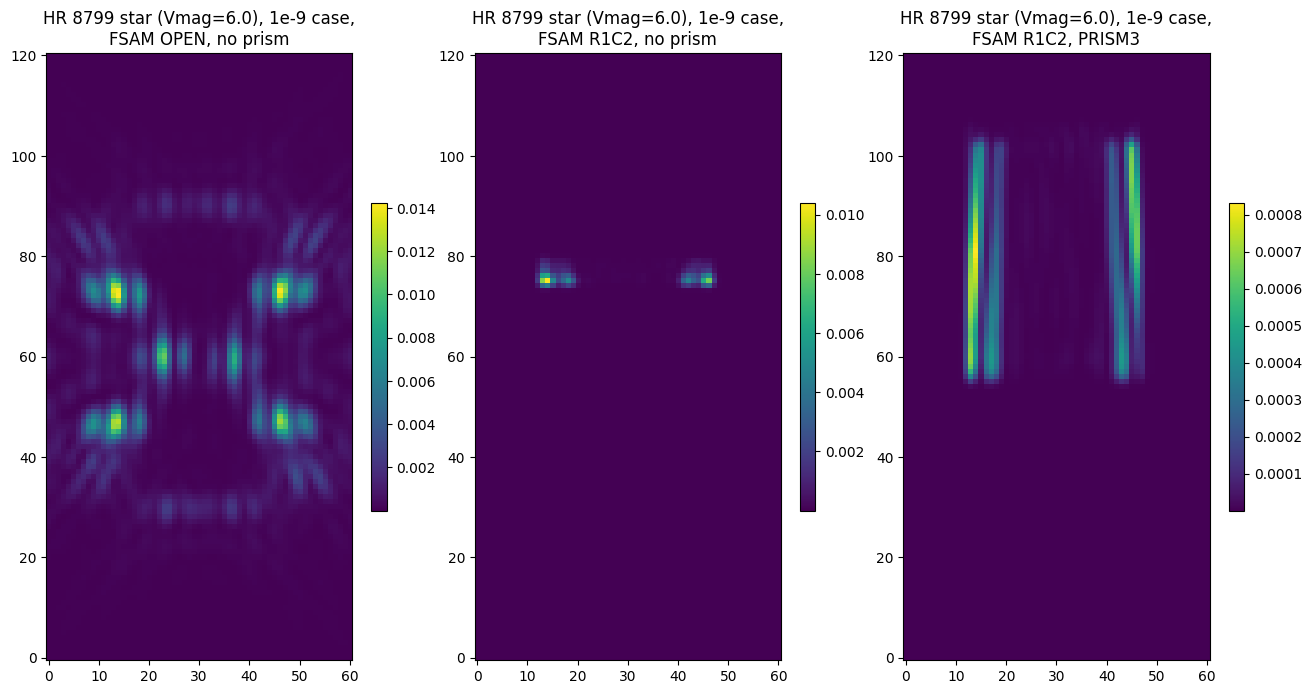

In [42]:
fig = plt.figure(figsize=(16,8))
plt.subplots_adjust(wspace=0.12)
xcrop = 30

plt.subplot(131)
plt.imshow(image_star_noslit_noprism[:,xcrop:-xcrop], origin='lower')
plt.title(f'HR 8799 star (Vmag={Vmag}), {cases[0]} case,\nFSAM OPEN, no prism')
plt.colorbar(shrink=0.5)

plt.subplot(132)
plt.imshow(image_star_slit_noprism[:,xcrop:-xcrop], origin='lower')
plt.title(f'HR 8799 star (Vmag={Vmag}), {cases[0]} case,\nFSAM R1C2, no prism')
plt.colorbar(shrink=0.5)

plt.subplot(133)
plt.imshow(image_star_slit_prism[:,xcrop:-xcrop], origin='lower')
plt.title(f'HR 8799 star (Vmag={Vmag}), {cases[0]} case,\nFSAM R1C2, PRISM3')
plt.colorbar(shrink=0.5)

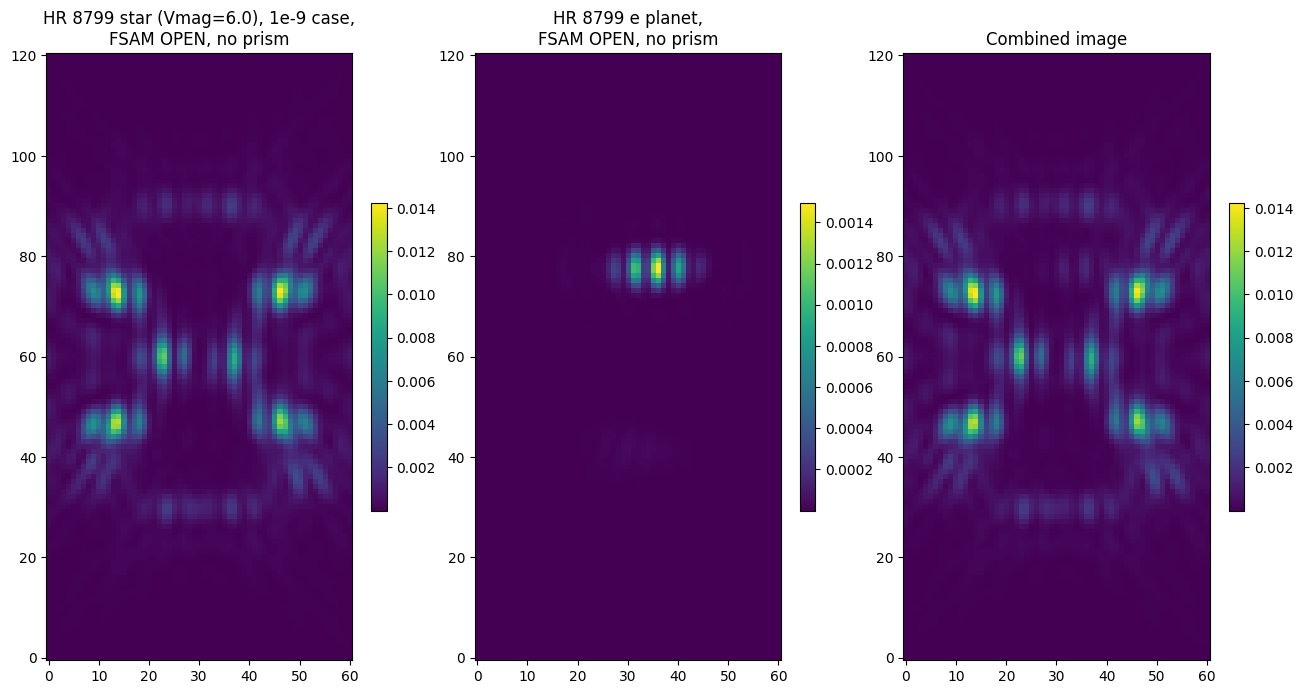

In [43]:
fig = plt.figure(figsize=(16,8))
plt.subplots_adjust(wspace=0.12)
xcrop = 30

plt.subplot(131)
plt.imshow(image_star_noslit_noprism[:,xcrop:-xcrop], origin='lower')
plt.title(f'HR 8799 star (Vmag={Vmag}), {cases[0]} case,\nFSAM OPEN, no prism')
plt.colorbar(shrink=0.5)

plt.subplot(132)
plt.imshow(image_comp_noslit_noprism[:,xcrop:-xcrop], origin='lower')
plt.title(f'HR 8799 e planet,\nFSAM OPEN, no prism')
plt.colorbar(shrink=0.5)

plt.subplot(133)
plt.imshow(combined_image_noslit_noprism[:,xcrop:-xcrop], origin='lower')
plt.title('Combined image')
plt.colorbar(shrink=0.5)

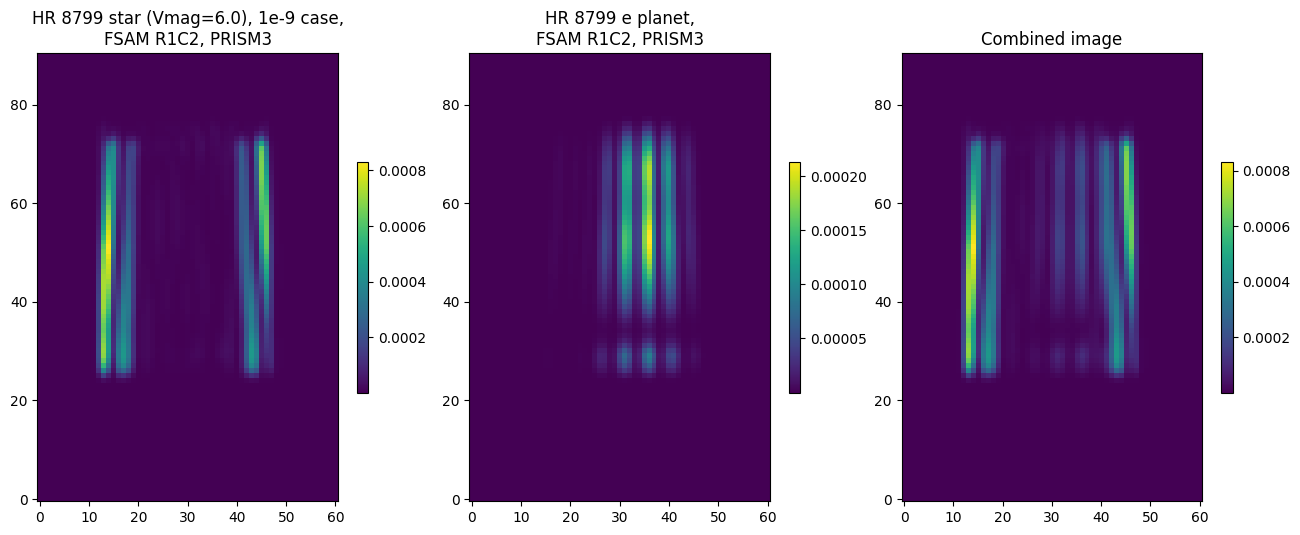

In [44]:
fig = plt.figure(figsize=(16,6))
plt.subplots_adjust(wspace=0.15)
xcrop = 30

plt.subplot(131)
plt.imshow(image_star_slit_prism[xcrop:,xcrop:-xcrop],origin='lower')
plt.title(f'HR 8799 star (Vmag={Vmag}), {cases[0]} case,\nFSAM R1C2, PRISM3')
plt.colorbar(shrink=0.5)

plt.subplot(132)
plt.imshow(image_comp_slit_prism[xcrop:,xcrop:-xcrop],origin='lower')
plt.title(f'HR 8799 e planet,\nFSAM R1C2, PRISM3')
plt.colorbar(shrink=0.5)

plt.subplot(133)
plt.imshow(combined_image_slit_prism[xcrop:,xcrop:-xcrop],origin='lower')
plt.title('Combined image')
plt.colorbar(shrink=0.5)

## 4. Detector Image

### Add detector noise

In [45]:
#simulate detector noise
gain =100
emccd_keywords ={'em_gain':gain, 'cr_rate':0}
detector = instrument.CorgiDetector(emccd_keywords)
exptime = 10000
#use configuration with slit and prism as example
sim_scene_slit_prism = detector.generate_detector_image(sim_scene_slit_prism,exptime)
image_tot_sub= sim_scene_slit_prism.image_on_detector.data

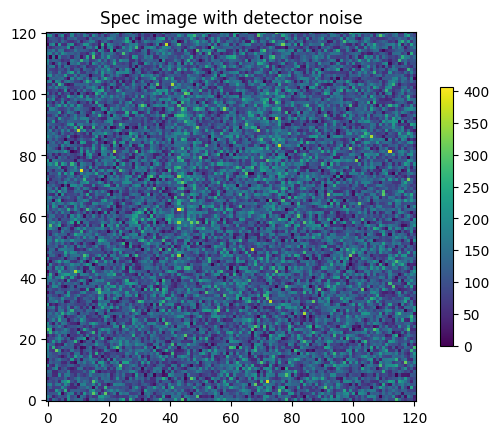

In [46]:
#plot image with detector noise
plt.imshow(image_tot_sub,origin='lower')
plt.title('Spec image with detector noise')

co = plt.colorbar(shrink=0.7)

### Full frame L1 image

In [47]:
#simulate full frame detector image
sim_scene_slit_prism = detector.generate_detector_image(sim_scene_slit_prism,exptime,full_frame=True,loc_x=512, loc_y=512)
image_tot_full = sim_scene_slit_prism.image_on_detector[1].data

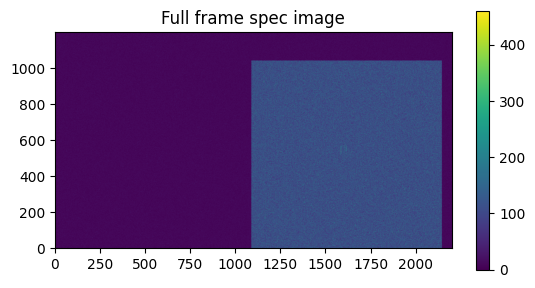

In [48]:
#plot full frame detector image
plt.imshow(image_tot_full,origin='lower')
plt.title('Full frame spec image')

co = plt.colorbar(shrink=0.7)